# Árboles de Decisión (CART) — Detección de Anemia Infantil (ENDES RECH6 2024)

Este notebook está **adaptado** de un ejemplo de árboles de decisión para
enfermedades cardíacas (`arbolesconheart.ipynb`), aplicando la misma
metodología —CART simple → CART optimizado (GridSearchCV + poda
`ccp_alpha`) → Árbol Difuso → Random Forest de referencia → validación
cruzada repetida → importancia de variables → predicción de casos nuevos→
guardado de modelos— al dataset **RECH6_2024** (Cuestionario Individual de
Salud del Niño, ENDES 2024).

Usa el **mismo dataset limpio de 17,798 niños y las mismas 9 variables**
(edad, peso, talla, 4 puntajes Z antropométricos, sexo, nivel educativo de
la madre) empleadas en los informes previos de Naive Bayes y Random Forest
del curso, para que los resultados sean comparables entre modelos.

**Variable objetivo:** `NivelAnemia` (Con\_Anemia / Sin\_Anemia), construida
desde `HC57A` (Nivel de Anemia, nueva directriz OMS 2024 / RM 251-2024-MINSA).

**Cómo usar este notebook en Google Colab:**
1. Ejecuta la primera celda de carga y sube el archivo `RECH6_2024.xlsx`
   cuando te lo pida (o móntalo desde tu Google Drive, ver comentario en la celda).
2. Ejecuta el resto de celdas en orden.


In [1]:
# =============================================================================
# ÁRBOLES DE DECISIÓN — ANEMIA INFANTIL (ENDES RECH6 2024)
# =============================================================================
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Scikit-learn
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RepeatedStratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

# scikit-fuzzy (para la Sección 5 — Árbol Difuso)
try:
    import skfuzzy as fuzz
except ImportError:
    import sys
    !pip install -q scikit-fuzzy
    import skfuzzy as fuzz

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.7 MB/s eta 0:00:00


In [2]:
# ================================================
# PALETA DE COLORES (compartida en todo el notebook)
# ================================================
PALETTE = {
    "primary":    "#2196F3",   # azul       -> CART Simple
    "secondary":  "#FF5722",   # naranja    -> CART Optimizado
    "tertiary":   "#4CAF50",   # verde      -> Random Forest
    "quaternary": "#9C27B0",   # púrpura    -> Árbol Difuso
    "bg":         "#F5F5F5",   # fondo claro
    "grid":       "#E0E0E0",   # líneas de cuadrícula
    "con_anemia": "#EF5350",   # clase Con_Anemia
    "sin_anemia": "#42A5F5",   # clase Sin_Anemia
}

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

def _fig_path(filename: str) -> str:
    """Devuelve la ruta completa dentro de figures/."""
    return os.path.join(FIGURES_DIR, filename)


## Sección 1 — Carga y Preprocesamiento de Datos

Reproducimos exactamente el mismo filtrado y las mismas 9 variables usadas
en los informes anteriores del curso (Naive Bayes, Random Forest), a partir
del módulo `RECH6` (Cuestionario Individual de Niños) de ENDES 2024:

1. `HC57A` en {1,2,3,4}: solo niños con hemoglobina efectivamente medida.
2. `HC2, HC3, HC70, HC71, HC72, HC73` < 9000: se descartan códigos de
   peso/talla/puntajes Z fuera de límites plausibles o marcados.
3. `HC61` en {0,1,2,3}: nivel educativo de la madre con código válido.

El resultado son **17,798 niños** con información completa y válida, y
**excluimos deliberadamente la hemoglobina** (`HC53/HC55/HC56/HC56A/HC57/HC57A`)
como *feature*, porque define directamente al target (fuga de información).


In [3]:
# --- Opción A: subir el archivo manualmente en Colab ---
try:
    from google.colab import files
    subido = files.upload()  # selecciona RECH6_2024.xlsx
    RUTA_ARCHIVO = list(subido.keys())[0]
except ImportError:
    RUTA_ARCHIVO = "RECH6_2024.xlsx"

# --- Opción B: montar Google Drive (alternativa) ---
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA_ARCHIVO = "/content/drive/MyDrive/ruta/a/RECH6_2024.xlsx"

print("=" * 70)
print("SECCIÓN 1 — CARGA Y PREPROCESAMIENTO DE DATOS")
print("=" * 70)

df_raw = pd.read_excel(RUTA_ARCHIVO)
print(f"\nDimensiones originales: {df_raw.shape}")

df = df_raw[df_raw["HC57A"].isin([1, 2, 3, 4])].copy()
for c in ["HC2", "HC3", "HC70", "HC71", "HC72", "HC73"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
mask = (
    (df["HC2"] < 9000) & (df["HC3"] < 9000) &
    (df["HC70"] < 9000) & (df["HC71"] < 9000) &
    (df["HC72"] < 9000) & (df["HC73"] < 9000)
)
df = df[mask].copy()
df["HC61"] = pd.to_numeric(df["HC61"], errors="coerce")
df = df[df["HC61"].isin([0, 1, 2, 3])].copy()

df["Edad_meses"]   = df["HC1"]
df["Peso_kg"]      = df["HC2"] / 10
df["Talla_cm"]     = df["HC3"] / 10
df["TallaEdad_DE"] = df["HC70"] / 100
df["PesoEdad_DE"]  = df["HC71"] / 100
df["PesoTalla_DE"] = df["HC72"] / 100
df["IMC_DE"]       = df["HC73"] / 100
df["Sexo"]         = df["HC27"].map({1: "Hombre", 2: "Mujer"})
df["EducMadre"]    = df["HC61"].map({0: "Sin_educacion", 1: "Primaria", 2: "Secundaria", 3: "Superior"})
df["NivelAnemia"]  = np.where(df["HC57A"].isin([1, 2, 3]), "Con_Anemia", "Sin_Anemia")

NUM_COLS = ["Edad_meses", "Peso_kg", "Talla_cm", "TallaEdad_DE", "PesoEdad_DE", "PesoTalla_DE", "IMC_DE"]
CAT_COLS = ["Sexo", "EducMadre"]
cols_modelo = NUM_COLS + CAT_COLS + ["NivelAnemia"]

df_model = df[cols_modelo].dropna().reset_index(drop=True)

print(f"\nDimensiones tras limpieza: {df_model.shape}")
print("\nPrimeras filas:")
print(df_model.head())
print("\nValores nulos por columna:")
nulos = df_model.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Ninguno")
print("\nDistribución de la variable objetivo:")
print(df_model["NivelAnemia"].value_counts())
print(df_model["NivelAnemia"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


Saving RECH6_2024.xlsx to RECH6_2024 (1).xlsx
SECCIÓN 1 — CARGA Y PREPROCESAMIENTO DE DATOS

Dimensiones originales: (20290, 43)

Dimensiones tras limpieza: (17798, 10)

Primeras filas:
   Edad_meses  Peso_kg  Talla_cm  TallaEdad_DE  PesoEdad_DE  PesoTalla_DE  \
0          43     15.0      96.2         -0.88        -0.10          0.60   
1          13      9.1      71.4         -1.67        -0.17          0.81   
2          19     11.9      80.2         -0.78         0.91          1.75   
3          13     10.0      74.7         -0.27         0.67          1.04   
4          18     11.2      79.5         -1.19         0.13          0.93   

   IMC_DE    Sexo   EducMadre NivelAnemia  
0    0.64   Mujer  Secundaria  Sin_Anemia  
1    1.11   Mujer  Secundaria  Sin_Anemia  
2    1.90   Mujer    Primaria  Sin_Anemia  
3    1.12   Mujer  Secundaria  Con_Anemia  
4    1.19  Hombre  Secundaria  Sin_Anemia  

Valores nulos por columna:
  Ninguno

Distribución de la variable objetivo:
NivelAnemi

## Sección 1.2 — Codificación y División Train/Test

Codificamos `Sexo` y `EducMadre` con **One-Hot Encoding** (igual que en el
informe de Naive Bayes/Random Forest) y dividimos 80/20 de forma
estratificada. Los árboles de decisión no requieren escalado (son
invariantes a transformaciones monótonas de los predictores), así que no
aplicamos `StandardScaler` aquí.


In [4]:
X = pd.get_dummies(df_model[NUM_COLS + CAT_COLS], columns=CAT_COLS, drop_first=False)
FEATURE_COLS = list(X.columns)

# Target codificado con orden fijo: Sin_Anemia=0, Con_Anemia=1
y = (df_model["NivelAnemia"] == "Con_Anemia").astype(int).values
CLASS_NAMES = ["Sin_Anemia", "Con_Anemia"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Predictores ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nEntrenamiento : {X_train.shape[0]} muestras")
print(f"Prueba        : {X_test.shape[0]} muestras")
print(f"Proporción de clases (train): {np.bincount(y_train) / len(y_train)}")
print(f"Proporción de clases (test) : {np.bincount(y_test) / len(y_test)}")


Predictores (13): ['Edad_meses', 'Peso_kg', 'Talla_cm', 'TallaEdad_DE', 'PesoEdad_DE', 'PesoTalla_DE', 'IMC_DE', 'Sexo_Hombre', 'Sexo_Mujer', 'EducMadre_Primaria', 'EducMadre_Secundaria', 'EducMadre_Sin_educacion', 'EducMadre_Superior']

Entrenamiento : 14238 muestras
Prueba        : 3560 muestras
Proporción de clases (train): [0.68485742 0.31514258]
Proporción de clases (test) : [0.68483146 0.31516854]


## Sección 2 — Análisis Exploratorio de Datos (EDA)


SECCIÓN 2 — ANÁLISIS EXPLORATORIO DE DATOS


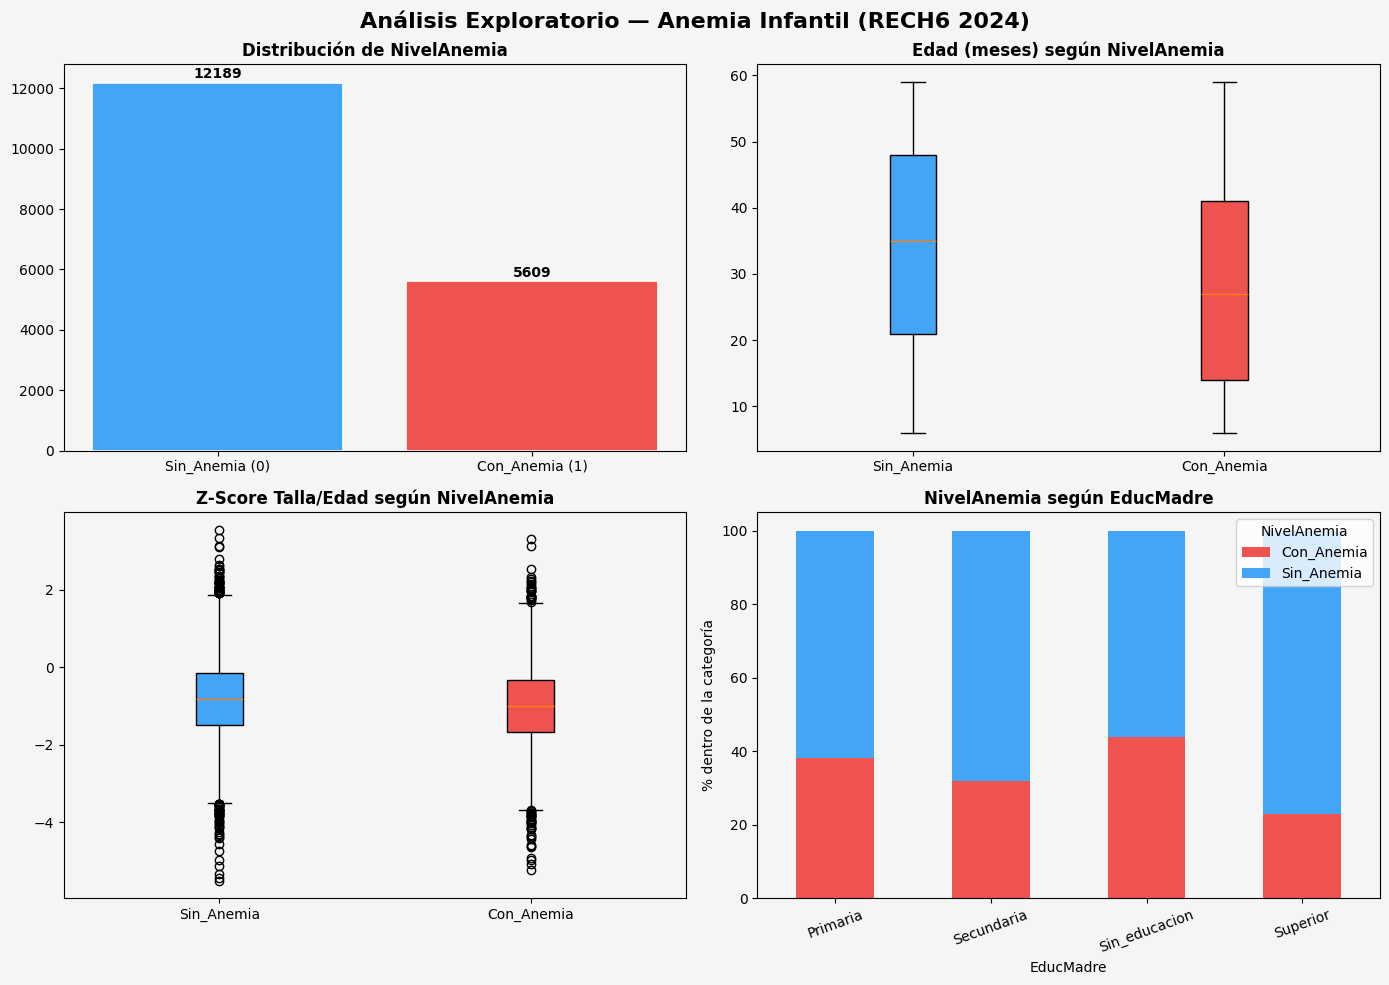

  → Figura guardada: figures/01_eda.png


In [5]:
print("\n" + "=" * 70)
print("SECCIÓN 2 — ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 70)

fig_eda, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_eda.suptitle("Análisis Exploratorio — Anemia Infantil (RECH6 2024)", fontsize=16, fontweight="bold")
fig_eda.patch.set_facecolor(PALETTE["bg"])

# 2.1 Distribución de clases
ax = axes[0, 0]
counts = pd.Series(y).value_counts().sort_index()
bars = ax.bar(
    ["Sin_Anemia (0)", "Con_Anemia (1)"],
    counts.values,
    color=[PALETTE["sin_anemia"], PALETTE["con_anemia"]],
    edgecolor="white", linewidth=1.2,
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+150, str(val), ha="center", fontweight="bold")
ax.set_title("Distribución de NivelAnemia", fontweight="bold")
ax.set_facecolor(PALETTE["bg"])

# 2.2 Boxplot Edad_meses por clase
ax = axes[0, 1]
data_edad = [df_model.loc[y == 0, "Edad_meses"], df_model.loc[y == 1, "Edad_meses"]]
bp = ax.boxplot(data_edad, labels=CLASS_NAMES, patch_artist=True)
for patch, color in zip(bp["boxes"], [PALETTE["sin_anemia"], PALETTE["con_anemia"]]):
    patch.set_facecolor(color)
ax.set_title("Edad (meses) según NivelAnemia", fontweight="bold")
ax.set_facecolor(PALETTE["bg"])

# 2.3 Boxplot TallaEdad_DE por clase
ax = axes[1, 0]
data_talla = [df_model.loc[y == 0, "TallaEdad_DE"], df_model.loc[y == 1, "TallaEdad_DE"]]
bp = ax.boxplot(data_talla, labels=CLASS_NAMES, patch_artist=True)
for patch, color in zip(bp["boxes"], [PALETTE["sin_anemia"], PALETTE["con_anemia"]]):
    patch.set_facecolor(color)
ax.set_title("Z-Score Talla/Edad según NivelAnemia", fontweight="bold")
ax.set_facecolor(PALETTE["bg"])

# 2.4 EducMadre según clase
ax = axes[1, 1]
tab = pd.crosstab(df_model["EducMadre"], df_model["NivelAnemia"], normalize="index") * 100
tab = tab[["Con_Anemia", "Sin_Anemia"]]
tab.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE["con_anemia"], PALETTE["sin_anemia"]])
ax.set_ylabel("% dentro de la categoría")
ax.set_title("NivelAnemia según EducMadre", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.set_facecolor(PALETTE["bg"])

plt.tight_layout()
eda_path = _fig_path("01_eda.png")
plt.savefig(eda_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Figura guardada: {eda_path}")


## Sección 3 — Árbol de Decisión CART (Modelo Base)

Entrenamos un árbol CART con hiperparámetros modestos (`max_depth=4`,
`min_samples_split=10`, `min_samples_leaf=5`) como línea base, antes de
optimizar.



SECCIÓN 3 — ÁRBOL DE DECISIÓN CART (MODELO BASE)

[CART Simple] Accuracy:          0.6913
[CART Simple] Balanced Accuracy: 0.5319
[CART Simple] F1 Macro:          0.4905

Reporte de clasificación:
              precision    recall  f1-score   support

  Sin_Anemia       0.70      0.96      0.81      2438
  Con_Anemia       0.56      0.10      0.17      1122

    accuracy                           0.69      3560
   macro avg       0.63      0.53      0.49      3560
weighted avg       0.65      0.69      0.61      3560



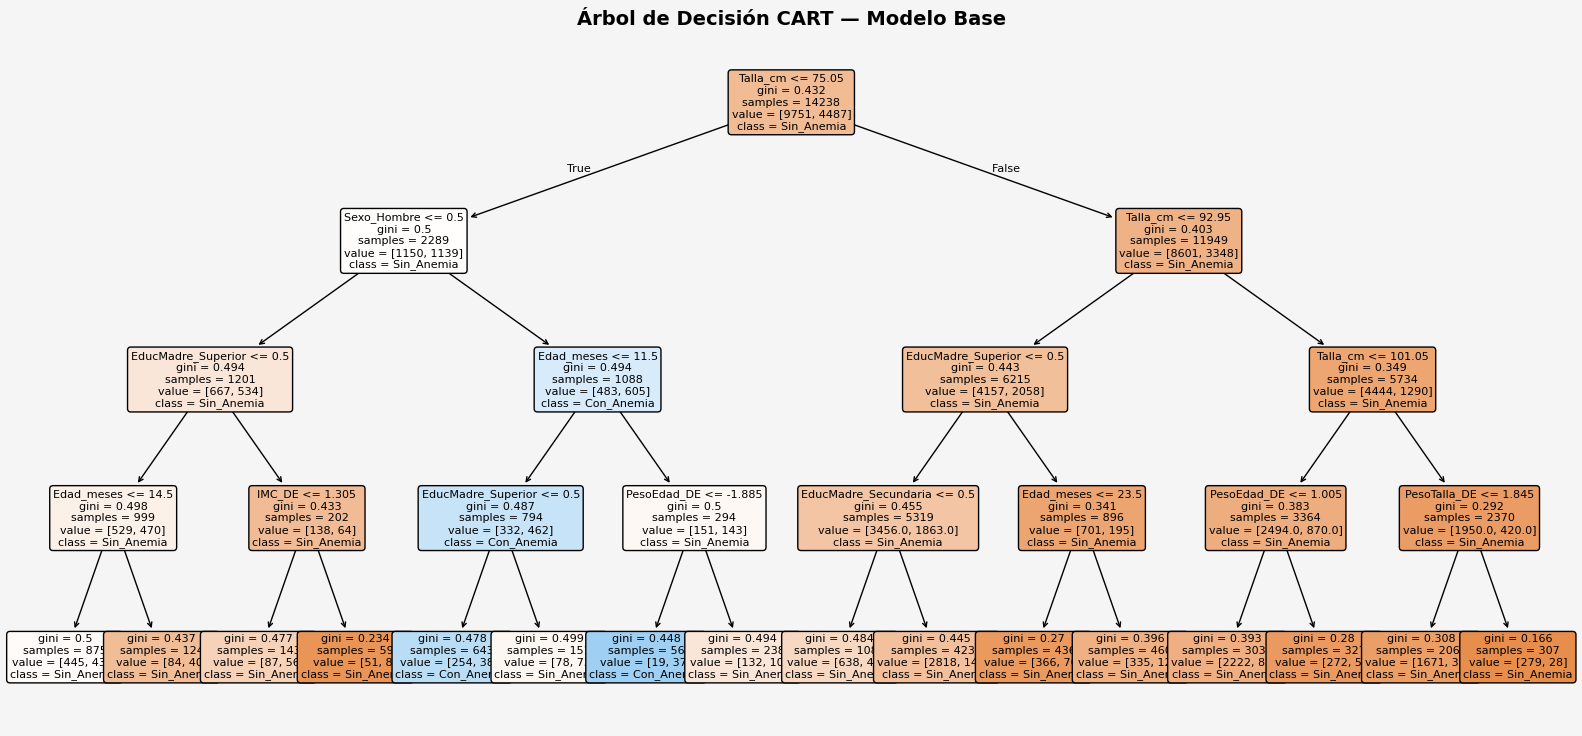

  → Figura guardada: figures/02_cart_tree.png

Reglas del árbol (texto):
|--- Talla_cm <= 75.05
|   |--- Sexo_Hombre <= 0.50
|   |   |--- EducMadre_Superior <= 0.50
|   |   |   |--- Edad_meses <= 14.50
|   |   |   |   |--- class: 0
|   |   |   |--- Edad_meses >  14.50
|   |   |   |   |--- class: 0
|   |   |--- EducMadre_Superior >  0.50
|   |   |   |--- IMC_DE <= 1.30
|   |   |   |   |--- class: 0
|   |   |   |--- IMC_DE >  1.30
|   |   |   |   |--- class: 0
|   |--- Sexo_Hombre >  0.50
|   |   |--- Edad_meses <= 11.50
|   |   |   |--- EducMadre_Superior <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- EducMadre_Superior >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Edad_meses >  11.50
|   |   |   |--- PesoEdad_DE <= -1.88
|   |   |   |   |--- class: 1
|   |   |   |--- PesoEdad_DE >  -1.88
|   |   |   |   |--- class: 0
|--- Talla_cm >  75.05
|   |--- Talla_cm <= 92.95
|   |   |--- EducMadre_Superior <= 0.50
|   |   |   |--- EducMadre_Secundaria <= 0.50
|   |   |   |   |--- c

In [6]:
print("\n" + "=" * 70)
print("SECCIÓN 3 — ÁRBOL DE DECISIÓN CART (MODELO BASE)")
print("=" * 70)

cart_simple = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
cart_simple.fit(X_train, y_train)

y_pred_simple = cart_simple.predict(X_test)
acc_simple  = accuracy_score(y_test, y_pred_simple)
bacc_simple = balanced_accuracy_score(y_test, y_pred_simple)
f1_simple   = f1_score(y_test, y_pred_simple, average="macro")

print(f"\n[CART Simple] Accuracy:          {acc_simple:.4f}")
print(f"[CART Simple] Balanced Accuracy: {bacc_simple:.4f}")
print(f"[CART Simple] F1 Macro:          {f1_simple:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_simple, target_names=CLASS_NAMES))

# Visualización del árbol simple
fig_tree, ax_tree = plt.subplots(figsize=(20, 9))
fig_tree.patch.set_facecolor(PALETTE["bg"])
plot_tree(
    cart_simple,
    feature_names=FEATURE_COLS,
    class_names=CLASS_NAMES,
    filled=True, rounded=True, fontsize=8, ax=ax_tree,
)
ax_tree.set_title("Árbol de Decisión CART — Modelo Base", fontsize=14, fontweight="bold")
tree_path = _fig_path("02_cart_tree.png")
plt.savefig(tree_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Figura guardada: {tree_path}")

print("\nReglas del árbol (texto):")
print(export_text(cart_simple, feature_names=FEATURE_COLS, max_depth=3))


## Sección 4 — Árbol CART Optimizado (GridSearchCV + poda `ccp_alpha`)

Calculamos la ruta de poda por costo-complejidad (`cost_complexity_pruning_path`)
del árbol simple para acotar los valores de `ccp_alpha` a explorar, y
optimizamos con `GridSearchCV` sobre `balanced_accuracy` (más adecuada que
`accuracy` dado el desbalance ~69%/31% de clases).



SECCIÓN 4 — ÁRBOL CART OPTIMIZADO (GridSearchCV + poda ccp_alpha)
Fitting 5 folds for each of 360 candidates, totalling 1800 fits

Mejores hiperparámetros: {'ccp_alpha': 0.00039, 'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 10}
Mejor Balanced Accuracy (CV): 0.5976

[CART Optimizado] Accuracy:          0.6143
[CART Optimizado] Balanced Accuracy: 0.5953
[CART Optimizado] F1 Macro:          0.5836

Reporte de clasificación:
              precision    recall  f1-score   support

  Sin_Anemia       0.75      0.65      0.70      2438
  Con_Anemia       0.41      0.54      0.47      1122

    accuracy                           0.61      3560
   macro avg       0.58      0.60      0.58      3560
weighted avg       0.65      0.61      0.63      3560



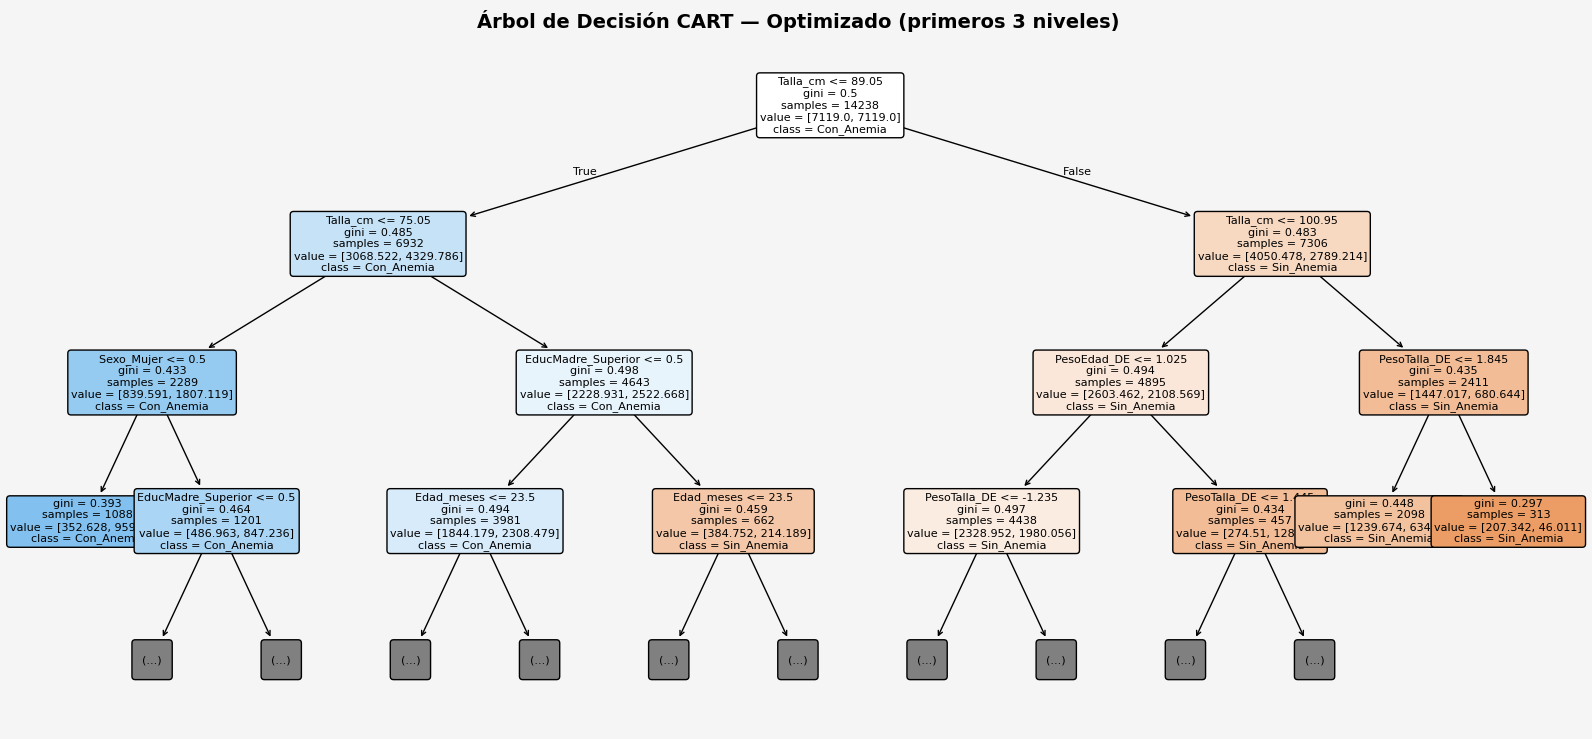

  → Figura guardada: figures/03_cart_tree_optimizado.png


In [7]:
print("\n" + "=" * 70)
print("SECCIÓN 4 — ÁRBOL CART OPTIMIZADO (GridSearchCV + poda ccp_alpha)")
print("=" * 70)

# 4.1 Ruta de poda por costo-complejidad
_ccp_path = cart_simple.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = _ccp_path.ccp_alphas

ccp_alphas_filtered = sorted(set(
    np.round(ccp_alphas[(ccp_alphas > 0) & (ccp_alphas < 0.02)], 5).tolist()
))
if len(ccp_alphas_filtered) == 0:
    ccp_alphas_filtered = [0.0, 0.001, 0.005]

# 4.2 Cuadrícula ajustada
param_grid = {
    "max_depth":         [3, 4, 5, 6],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf":  [5, 10, 15],
    "class_weight":      [None, "balanced"],
    "ccp_alpha":         ccp_alphas_filtered[:5],
}

cv_inner = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_inner,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f"\nMejores hiperparámetros: {best_params}")
print(f"Mejor Balanced Accuracy (CV): {grid_search.best_score_:.4f}")

cart_opt = grid_search.best_estimator_

y_pred_opt = cart_opt.predict(X_test)
acc_opt  = accuracy_score(y_test, y_pred_opt)
bacc_opt = balanced_accuracy_score(y_test, y_pred_opt)
f1_opt   = f1_score(y_test, y_pred_opt, average="macro")

print(f"\n[CART Optimizado] Accuracy:          {acc_opt:.4f}")
print(f"[CART Optimizado] Balanced Accuracy: {bacc_opt:.4f}")
print(f"[CART Optimizado] F1 Macro:          {f1_opt:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_opt, target_names=CLASS_NAMES))

# Visualización del árbol optimizado (recortado a profundidad 3 para legibilidad)
fig_tree_opt, ax_tree_opt = plt.subplots(figsize=(20, 9))
fig_tree_opt.patch.set_facecolor(PALETTE["bg"])
plot_tree(
    cart_opt,
    feature_names=FEATURE_COLS,
    class_names=CLASS_NAMES,
    filled=True, rounded=True, fontsize=8, ax=ax_tree_opt,
    max_depth=3,
)
ax_tree_opt.set_title("Árbol de Decisión CART — Optimizado (primeros 3 niveles)", fontsize=14, fontweight="bold")
tree_opt_path = _fig_path("03_cart_tree_optimizado.png")
plt.savefig(tree_opt_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Figura guardada: {tree_opt_path}")


## Sección 5 — Árbol Difuso (Fuzzy Decision Tree)

Como en el ejemplo de referencia, construimos un **puntaje difuso de
riesgo de anemia** a partir de funciones de membresía gaussianas
(`gaussmf`) sobre variables clínicamente relevantes: edad, puntaje Z
Talla/Edad y puntaje Z Peso/Edad. Cada variable aporta un grado de
membresía "alto riesgo"; el puntaje final es el promedio de esos grados,
y se optimiza el **umbral de decisión** sobre el conjunto de
entrenamiento maximizando F1.


In [8]:
print("\n" + "=" * 70)
print("SECCIÓN 5 — ÁRBOL DIFUSO (Fuzzy Decision Tree)")
print("=" * 70)

def _gaussmf(x: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    """Función de membresía gaussiana: exp(-0.5 * ((x - mean)/sigma)^2)."""
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)


def _fuzzy_score_anemia(row: dict) -> float:
    """
    Calcula un puntaje difuso [0,1] de riesgo de anemia para un niño,
    combinando edad y puntajes Z antropométricos (más negativos = mayor
    riesgo de desnutrición crónica/aguda, asociada a mayor riesgo de anemia).
    """
    # Edad: mayor riesgo de anemia en primera infancia (6-24 meses)
    edad = row.get("Edad_meses", 30.0)
    mu_edad_riesgo = _gaussmf(np.array([edad]), mean=15.0, sigma=10.0)[0]

    # TallaEdad_DE: mientras más negativo, mayor riesgo (stunting)
    talla_de = row.get("TallaEdad_DE", 0.0)
    mu_talla_riesgo = _gaussmf(np.array([talla_de]), mean=-2.5, sigma=1.2)[0]

    # PesoEdad_DE: mientras más negativo, mayor riesgo (bajo peso)
    peso_de = row.get("PesoEdad_DE", 0.0)
    mu_peso_riesgo = _gaussmf(np.array([peso_de]), mean=-2.0, sigma=1.2)[0]

    return float(np.mean([mu_edad_riesgo, mu_talla_riesgo, mu_peso_riesgo]))


# Puntaje difuso sobre train y test
scores_train = np.array([
    _fuzzy_score_anemia(dict(zip(FEATURE_COLS, row))) for row in X_train.values
])
scores_test = np.array([
    _fuzzy_score_anemia(dict(zip(FEATURE_COLS, row))) for row in X_test.values
])

# Optimización del umbral sobre TRAIN (maximiza F1)
mejores_thr = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_train, (scores_train >= t).astype(int)) for t in mejores_thr]
optimal_threshold = mejores_thr[int(np.argmax(f1s))]

y_pred_fuzzy = (scores_test >= optimal_threshold).astype(int)
acc_fuzzy  = accuracy_score(y_test, y_pred_fuzzy)
bacc_fuzzy = balanced_accuracy_score(y_test, y_pred_fuzzy)
f1_fuzzy   = f1_score(y_test, y_pred_fuzzy, average="macro")

print(f"\nUmbral óptimo (F1, train): {optimal_threshold:.3f}")
print(f"[Fuzzy Tree] Accuracy:          {acc_fuzzy:.4f}")
print(f"[Fuzzy Tree] Balanced Accuracy: {bacc_fuzzy:.4f}")
print(f"[Fuzzy Tree] F1 Macro:          {f1_fuzzy:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_fuzzy, target_names=CLASS_NAMES))



SECCIÓN 5 — ÁRBOL DIFUSO (Fuzzy Decision Tree)

Umbral óptimo (F1, train): 0.190
[Fuzzy Tree] Accuracy:          0.4340
[Fuzzy Tree] Balanced Accuracy: 0.5466
[Fuzzy Tree] F1 Macro:          0.4280

Reporte de clasificación:
              precision    recall  f1-score   support

  Sin_Anemia       0.78      0.24      0.37      2438
  Con_Anemia       0.34      0.85      0.49      1122

    accuracy                           0.43      3560
   macro avg       0.56      0.55      0.43      3560
weighted avg       0.64      0.43      0.41      3560



## Sección 6 — Random Forest (Benchmark Robusto)

Como en el ejemplo de referencia, entrenamos un Random Forest con
`class_weight="balanced"` para tener un punto de comparación robusto
frente a los árboles individuales.


In [9]:
print("\n" + "=" * 70)
print("SECCIÓN 6 — RANDOM FOREST (Benchmark Robusto)")
print("=" * 70)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf  = accuracy_score(y_test, y_pred_rf)
bacc_rf = balanced_accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf, average="macro")

print(f"\n[Random Forest] Accuracy:          {acc_rf:.4f}")
print(f"[Random Forest] Balanced Accuracy: {bacc_rf:.4f}")
print(f"[Random Forest] F1 Macro:          {f1_rf:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))



SECCIÓN 6 — RANDOM FOREST (Benchmark Robusto)

[Random Forest] Accuracy:          0.6551
[Random Forest] Balanced Accuracy: 0.5591
[Random Forest] F1 Macro:          0.5592

Reporte de clasificación:
              precision    recall  f1-score   support

  Sin_Anemia       0.72      0.82      0.76      2438
  Con_Anemia       0.43      0.30      0.35      1122

    accuracy                           0.66      3560
   macro avg       0.57      0.56      0.56      3560
weighted avg       0.63      0.66      0.64      3560



## Sección 7 — Validación Cruzada Repetida (5 folds × 3 repeticiones)

Evaluamos CART Simple, CART Optimizado y Random Forest con
`RepeatedStratifiedKFold` para obtener estimaciones más estables que una
única partición train/test. El Árbol Difuso no es un estimador de
`scikit-learn` (usa una función de membresía manual), así que su CV se
reporta por separado con una implementación manual equivalente.


In [10]:
print("\n" + "=" * 70)
print("SECCIÓN 7 — VALIDACIÓN CRUZADA REPETIDA (5 folds × 3 repeticiones)")
print("=" * 70)

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
SCORING = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro":          "f1_macro",
}

models_cv = {
    "CART Simple":     cart_simple,
    "CART Optimizado": cart_opt,
    "Random Forest":   rf_model,
}

cv_results_summary = {}
for model_name, model in models_cv.items():
    cv_res = cross_validate(model, X, y, cv=CV_OUTER, scoring=SCORING, n_jobs=-1)
    cv_results_summary[model_name] = {
        "Accuracy (μ±σ)":      f"{cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std():.4f}",
        "Bal. Accuracy (μ±σ)": f"{cv_res['test_balanced_accuracy'].mean():.4f} ± {cv_res['test_balanced_accuracy'].std():.4f}",
        "F1 Macro (μ±σ)":      f"{cv_res['test_f1_macro'].mean():.4f} ± {cv_res['test_f1_macro'].std():.4f}",
    }
    print(f"\n  {model_name}:")
    for metric, val in cv_results_summary[model_name].items():
        print(f"    {metric}: {val}")

# CV manual para el Árbol Difuso (mismo esquema 5x3, sin reentrenar nada: el
# puntaje difuso no tiene parámetros ajustables por fold, solo se recalcula
# el umbral óptimo en cada fold de entrenamiento)
fuzzy_accs, fuzzy_baccs, fuzzy_f1s = [], [], []
X_np = X.values
for tr_idx, te_idx in CV_OUTER.split(X_np, y):
    Xtr, Xte = X_np[tr_idx], X_np[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    s_tr = np.array([_fuzzy_score_anemia(dict(zip(FEATURE_COLS, r))) for r in Xtr])
    s_te = np.array([_fuzzy_score_anemia(dict(zip(FEATURE_COLS, r))) for r in Xte])
    thrs = np.linspace(0.05, 0.95, 46)
    f1s_fold = [f1_score(ytr, (s_tr >= t).astype(int)) for t in thrs]
    thr_fold = thrs[int(np.argmax(f1s_fold))]
    pred_te = (s_te >= thr_fold).astype(int)
    fuzzy_accs.append(accuracy_score(yte, pred_te))
    fuzzy_baccs.append(balanced_accuracy_score(yte, pred_te))
    fuzzy_f1s.append(f1_score(yte, pred_te, average="macro"))

cv_results_summary["Fuzzy Tree"] = {
    "Accuracy (μ±σ)":      f"{np.mean(fuzzy_accs):.4f} ± {np.std(fuzzy_accs):.4f}",
    "Bal. Accuracy (μ±σ)": f"{np.mean(fuzzy_baccs):.4f} ± {np.std(fuzzy_baccs):.4f}",
    "F1 Macro (μ±σ)":      f"{np.mean(fuzzy_f1s):.4f} ± {np.std(fuzzy_f1s):.4f}",
}
print(f"\n  Fuzzy Tree (CV manual):")
for metric, val in cv_results_summary["Fuzzy Tree"].items():
    print(f"    {metric}: {val}")



SECCIÓN 7 — VALIDACIÓN CRUZADA REPETIDA (5 folds × 3 repeticiones)

  CART Simple:
    Accuracy (μ±σ): 0.6911 ± 0.0036
    Bal. Accuracy (μ±σ): 0.5496 ± 0.0091
    F1 Macro (μ±σ): 0.5288 ± 0.0170

  CART Optimizado:
    Accuracy (μ±σ): 0.6078 ± 0.0213
    Bal. Accuracy (μ±σ): 0.5986 ± 0.0096
    F1 Macro (μ±σ): 0.5819 ± 0.0140

  Random Forest:
    Accuracy (μ±σ): 0.6569 ± 0.0038
    Bal. Accuracy (μ±σ): 0.5613 ± 0.0052
    F1 Macro (μ±σ): 0.5616 ± 0.0058

  Fuzzy Tree (CV manual):
    Accuracy (μ±σ): 0.4374 ± 0.0074
    Bal. Accuracy (μ±σ): 0.5528 ± 0.0061
    F1 Macro (μ±σ): 0.4307 ± 0.0084


## Sección 8 — Matrices de Confusión Comparativas


SECCIÓN 8 — MATRICES DE CONFUSIÓN


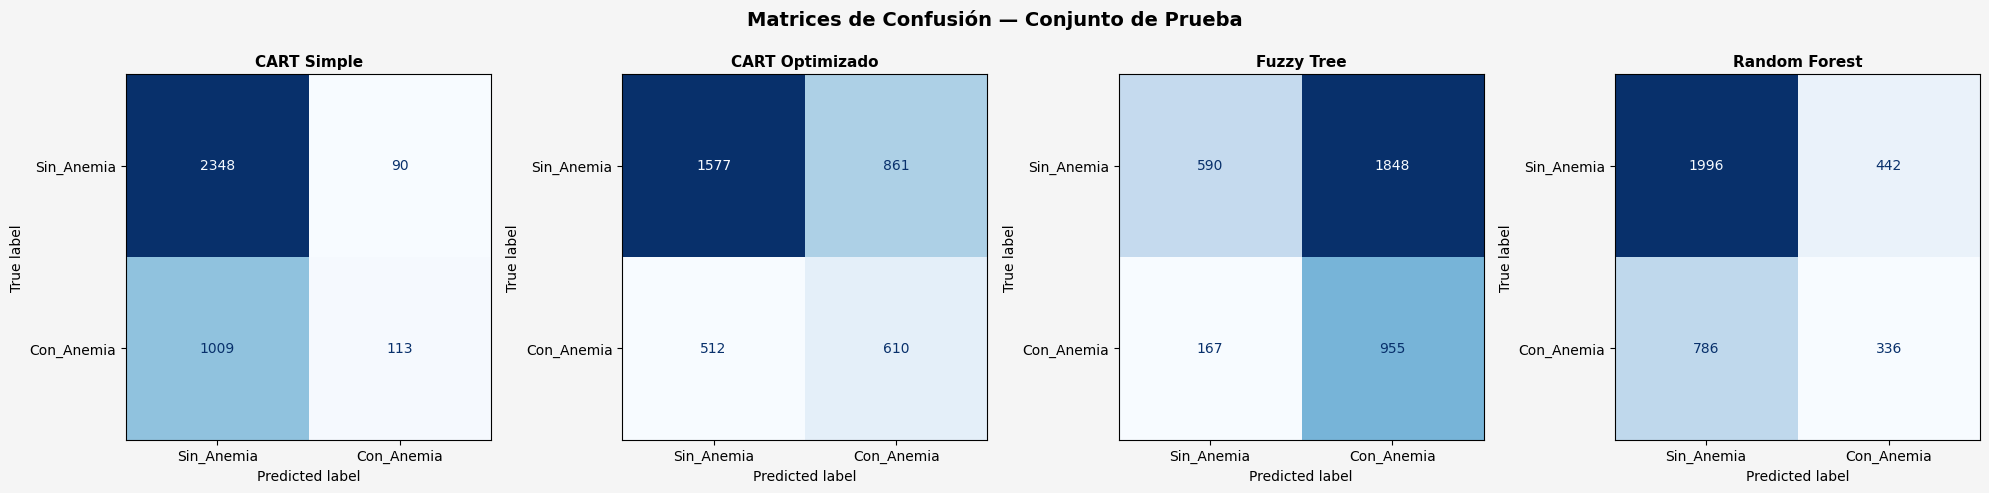

  → Figura guardada: figures/04_confusion_matrices.png


In [11]:
print("\n" + "=" * 70)
print("SECCIÓN 8 — MATRICES DE CONFUSIÓN")
print("=" * 70)

fig_cm, axs_cm = plt.subplots(1, 4, figsize=(20, 5))
fig_cm.suptitle("Matrices de Confusión — Conjunto de Prueba", fontsize=14, fontweight="bold")
fig_cm.patch.set_facecolor(PALETTE["bg"])

cm_pairs = [
    ("CART Simple",     y_pred_simple, PALETTE["primary"]),
    ("CART Optimizado", y_pred_opt,    PALETTE["secondary"]),
    ("Fuzzy Tree",      y_pred_fuzzy,  PALETTE["quaternary"]),
    ("Random Forest",   y_pred_rf,     PALETTE["tertiary"]),
]

for ax_cm, (name, y_pred_cm, color) in zip(axs_cm, cm_pairs):
    cm = confusion_matrix(y_test, y_pred_cm)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(name, fontweight="bold", fontsize=11)
    ax_cm.set_facecolor(PALETTE["bg"])

plt.tight_layout()
cm_path = _fig_path("04_confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Figura guardada: {cm_path}")


## Sección 9 — Importancia de Características + Permutation Importance


SECCIÓN 9 — IMPORTANCIA DE CARACTERÍSTICAS


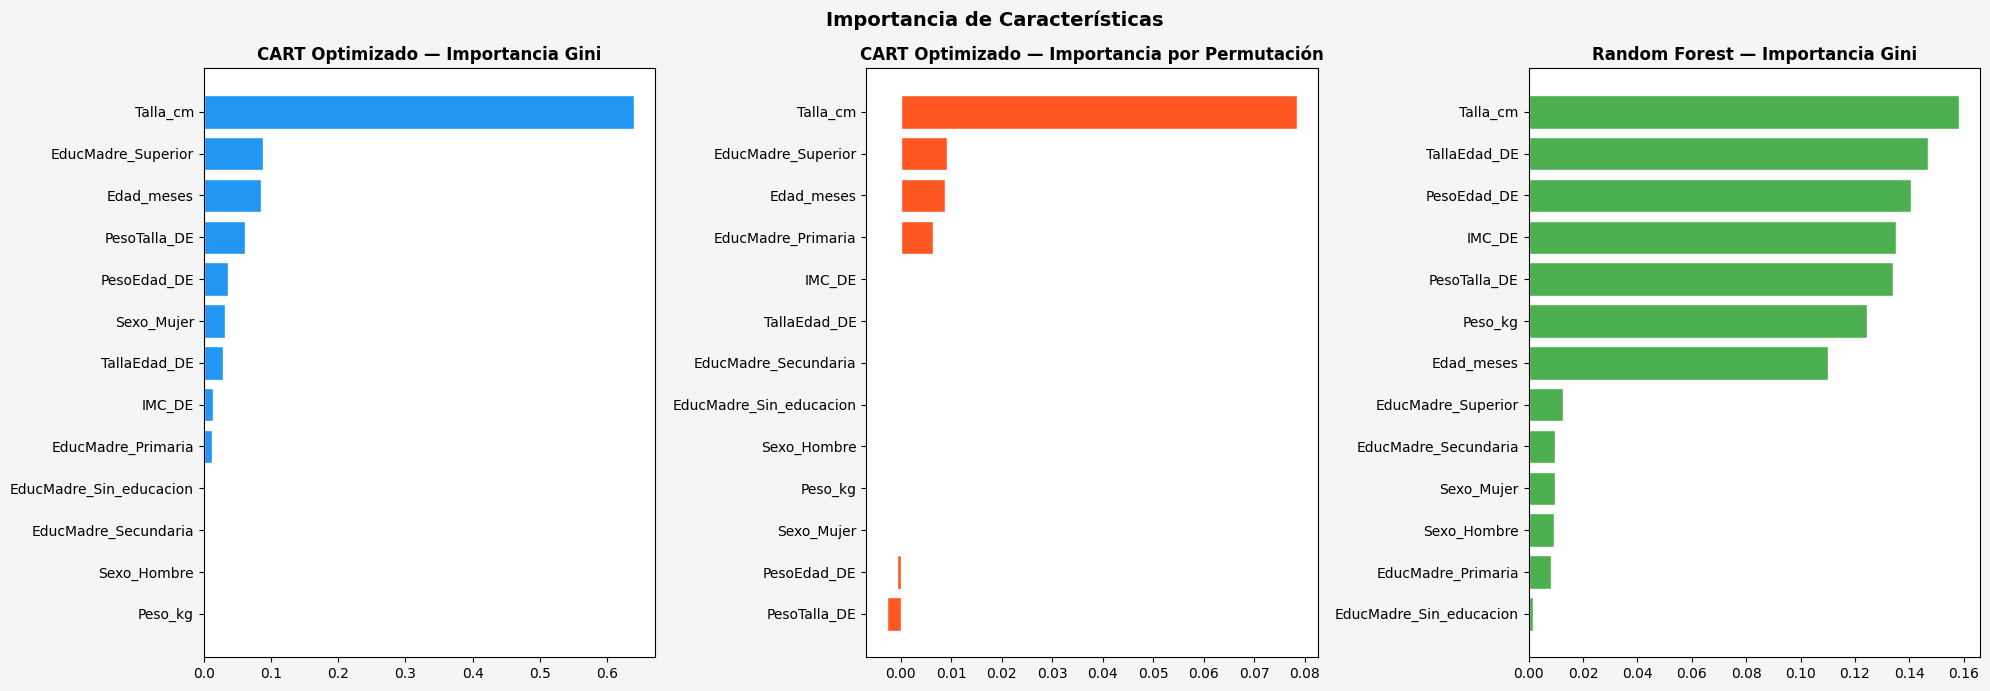

  → Figura guardada: figures/05_importancia_variables.png


In [12]:
print("\n" + "=" * 70)
print("SECCIÓN 9 — IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 70)

# 9.1 Importancia intrínseca (Gini) del CART optimizado
feat_importances_cart = cart_opt.feature_importances_
sorted_idx_cart = np.argsort(feat_importances_cart)[::-1]

# 9.2 Importancia por permutación (más robusta y no sesgada)
perm_imp = permutation_importance(
    cart_opt, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="balanced_accuracy",
)
perm_means = perm_imp.importances_mean
sorted_idx_perm = np.argsort(perm_means)[::-1]

# 9.3 Importancia del Random Forest
feat_importances_rf = rf_model.feature_importances_
sorted_idx_rf = np.argsort(feat_importances_rf)[::-1]

fig_imp, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))
fig_imp.suptitle("Importancia de Características", fontsize=14, fontweight="bold")
fig_imp.patch.set_facecolor(PALETTE["bg"])

ax1.barh([FEATURE_COLS[i] for i in sorted_idx_cart], feat_importances_cart[sorted_idx_cart],
         color=PALETTE["primary"], edgecolor="white")
ax1.set_title("CART Optimizado — Importancia Gini", fontweight="bold")
ax1.invert_yaxis()

ax2.barh([FEATURE_COLS[i] for i in sorted_idx_perm], perm_means[sorted_idx_perm],
         color=PALETTE["secondary"], edgecolor="white")
ax2.set_title("CART Optimizado — Importancia por Permutación", fontweight="bold")
ax2.invert_yaxis()

ax3.barh([FEATURE_COLS[i] for i in sorted_idx_rf], feat_importances_rf[sorted_idx_rf],
         color=PALETTE["tertiary"], edgecolor="white")
ax3.set_title("Random Forest — Importancia Gini", fontweight="bold")
ax3.invert_yaxis()

plt.tight_layout()
imp_path = _fig_path("05_importancia_variables.png")
plt.savefig(imp_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  → Figura guardada: {imp_path}")


## Sección 10 — Tabla Resumen Ejecutivo

In [13]:
print("\n" + "=" * 70)
print("SECCIÓN 10 — TABLA RESUMEN EJECUTIVO")
print("=" * 70)

summary_data = {
    "Modelo": ["CART Simple", "CART Optimizado", "Fuzzy Tree", "Random Forest"],
    "Accuracy (test)":   [f"{acc_simple:.4f}",  f"{acc_opt:.4f}",  f"{acc_fuzzy:.4f}",  f"{acc_rf:.4f}"],
    "Bal. Acc. (test)":  [f"{bacc_simple:.4f}", f"{bacc_opt:.4f}", f"{bacc_fuzzy:.4f}", f"{bacc_rf:.4f}"],
    "F1 Macro (test)":   [f"{f1_simple:.4f}",   f"{f1_opt:.4f}",   f"{f1_fuzzy:.4f}",   f"{f1_rf:.4f}"],
    "Accuracy CV (μ±σ)":      [cv_results_summary[m]["Accuracy (μ±σ)"] for m in ["CART Simple","CART Optimizado","Fuzzy Tree","Random Forest"]],
    "Bal. Acc. CV (μ±σ)":     [cv_results_summary[m]["Bal. Accuracy (μ±σ)"] for m in ["CART Simple","CART Optimizado","Fuzzy Tree","Random Forest"]],
    "F1 Macro CV (μ±σ)":      [cv_results_summary[m]["F1 Macro (μ±σ)"] for m in ["CART Simple","CART Optimizado","Fuzzy Tree","Random Forest"]],
}
resumen_df = pd.DataFrame(summary_data)
print(resumen_df.to_string(index=False))

mejor_modelo = summary_data["Modelo"][int(np.argmax([float(v) for v in summary_data["Bal. Acc. (test)"]]))]
print(f"\n★ Mejor modelo (Balanced Accuracy en test): {mejor_modelo}")



SECCIÓN 10 — TABLA RESUMEN EJECUTIVO
         Modelo Accuracy (test) Bal. Acc. (test) F1 Macro (test) Accuracy CV (μ±σ) Bal. Acc. CV (μ±σ) F1 Macro CV (μ±σ)
    CART Simple          0.6913           0.5319          0.4905   0.6911 ± 0.0036    0.5496 ± 0.0091   0.5288 ± 0.0170
CART Optimizado          0.6143           0.5953          0.5836   0.6078 ± 0.0213    0.5986 ± 0.0096   0.5819 ± 0.0140
     Fuzzy Tree          0.4340           0.5466          0.4280   0.4374 ± 0.0074    0.5528 ± 0.0061   0.4307 ± 0.0084
  Random Forest          0.6551           0.5591          0.5592   0.6569 ± 0.0038    0.5613 ± 0.0052   0.5616 ± 0.0058

★ Mejor modelo (Balanced Accuracy en test): CART Optimizado


## Sección 11 — Función de Predicción para un Niño Nuevo

Usamos el **CART Optimizado** (`cart_opt`) para predecir el riesgo de
anemia de un niño nuevo, sin necesidad de reentrenar nada — el modelo y
las columnas dummy ya están ajustados en memoria.


In [14]:
print("\n" + "=" * 70)
print("SECCIÓN 11 — FUNCIÓN DE PREDICCIÓN PARA UN NIÑO NUEVO")
print("=" * 70)

def predict_anemia_infantil(
    edad_meses: float,
    peso_kg: float,
    talla_cm: float,
    talla_edad_de: float,
    peso_edad_de: float,
    peso_talla_de: float,
    imc_de: float,
    sexo: str,           # 'Hombre' | 'Mujer'
    educ_madre: str,     # 'Sin_educacion' | 'Primaria' | 'Secundaria' | 'Superior'
    model=None,
    feature_cols=None,
) -> dict:
    """
    Predice el nivel de anemia para un niño nuevo usando el CART optimizado
    (por defecto). Devuelve la clase predicha y la probabilidad de Con_Anemia.
    """
    model = model if model is not None else cart_opt
    feature_cols = feature_cols if feature_cols is not None else FEATURE_COLS

    fila = pd.DataFrame([{
        "Edad_meses": edad_meses, "Peso_kg": peso_kg, "Talla_cm": talla_cm,
        "TallaEdad_DE": talla_edad_de, "PesoEdad_DE": peso_edad_de,
        "PesoTalla_DE": peso_talla_de, "IMC_DE": imc_de,
        "Sexo": sexo, "EducMadre": educ_madre,
    }])
    fila_enc = pd.get_dummies(fila, columns=CAT_COLS, drop_first=False)
    for c in feature_cols:
        if c not in fila_enc.columns:
            fila_enc[c] = 0
    fila_enc = fila_enc[feature_cols]

    prob_con_anemia = model.predict_proba(fila_enc)[0][1]
    pred_clase = CLASS_NAMES[int(model.predict(fila_enc)[0])]

    return {"prediccion": pred_clase, "probabilidad_con_anemia": round(float(prob_con_anemia), 4)}


# Ejemplo de uso
resultado = predict_anemia_infantil(
    edad_meses=18, peso_kg=9.8, talla_cm=78.5,
    talla_edad_de=-1.8, peso_edad_de=-1.2, peso_talla_de=-0.5, imc_de=-0.6,
    sexo="Mujer", educ_madre="Secundaria",
)
print("Predicción — niño de ejemplo (CART Optimizado):")
for k, v in resultado.items():
    print(f"  {k}: {v}")



SECCIÓN 11 — FUNCIÓN DE PREDICCIÓN PARA UN NIÑO NUEVO
Predicción — niño de ejemplo (CART Optimizado):
  prediccion: Con_Anemia
  probabilidad_con_anemia: 0.5633


## Sección 12 — Guardado de Modelos con `joblib`

In [15]:
print("\n" + "=" * 70)
print("SECCIÓN 12 — GUARDADO DE MODELOS")
print("=" * 70)

models_to_save = {
    "cart_simple":    cart_simple,
    "cart_optimizado": cart_opt,
    "random_forest":  rf_model,
}
for model_name, model_obj in models_to_save.items():
    model_path = os.path.join(MODELS_DIR, f"{model_name}.joblib")
    joblib.dump(model_obj, model_path)
    print(f"  Guardado: {model_path}")

fuzzy_meta = {
    "optimal_threshold": optimal_threshold,
    "feature_cols": FEATURE_COLS,
    "gaussmf_params": {
        "edad":      {"riesgo": (15.0, 10.0)},
        "talla_de":  {"riesgo": (-2.5, 1.2)},
        "peso_de":   {"riesgo": (-2.0, 1.2)},
    },
}
fuzzy_meta_path = os.path.join(MODELS_DIR, "fuzzy_tree_meta.joblib")
joblib.dump(fuzzy_meta, fuzzy_meta_path)
print(f"  Guardado: {fuzzy_meta_path}")

print("\n" + "=" * 70)
print("  PROCESO COMPLETADO EXITOSAMENTE")
print(f"  Figuras guardadas en: ./{FIGURES_DIR}/")
print(f"  Modelos guardados en: ./{MODELS_DIR}/")
print("=" * 70)



SECCIÓN 12 — GUARDADO DE MODELOS
  Guardado: models/cart_simple.joblib
  Guardado: models/cart_optimizado.joblib
  Guardado: models/random_forest.joblib
  Guardado: models/fuzzy_tree_meta.joblib

  PROCESO COMPLETADO EXITOSAMENTE
  Figuras guardadas en: ./figures/
  Modelos guardados en: ./models/
